<a href="https://colab.research.google.com/github/cabamarcos/CIFAR10_CNN/blob/main/muinar06_act2_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [7]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# La incluimos para ayudarte con la identificación de clases. De ti depende
# si quieres utilizar esta variable o no
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [8]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

## Análisis exploratorio de los datos

Primero vamos a ver el tamaño de los datasets y las imágenes

In [6]:
print("Tamaño de una imagen (altura, anchura, canales):", x_train[0].shape)

print("Forma del conjunto de entrenamiento:", x_train.shape)
print("Forma del conjunto de validación:", x_valid.shape)
print("Forma del conjunto de test:", x_test.shape)


Tamaño de una imagen (altura, anchura, canales): (32, 32, 3)
Forma del conjunto de entrenamiento: (40000, 32, 32, 3)
Forma del conjunto de validación: (10000, 32, 32, 3)
Forma del conjunto de test: (10000, 32, 32, 3)


En la siguiente celda vamos a ver la primera imágen de cada clase del dataset

<ipython-input-7-38e3afeaa2fe>:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(y_train[i])


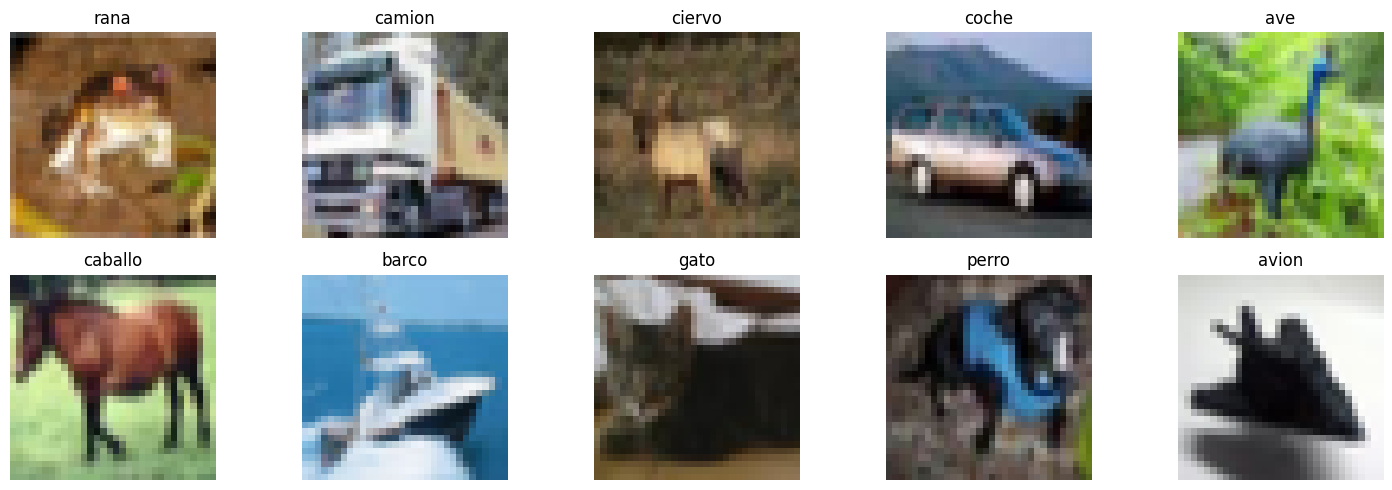

In [7]:
samples = {}
for i in range(len(y_train)):
    label = int(y_train[i])
    if label not in samples:
        samples[label] = x_train[i]
    if len(samples) == 10:
        break

plt.figure(figsize=(15, 5))
for idx, (label, image) in enumerate(samples.items()):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(image)
    plt.title(MAP_ELEMENTS[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

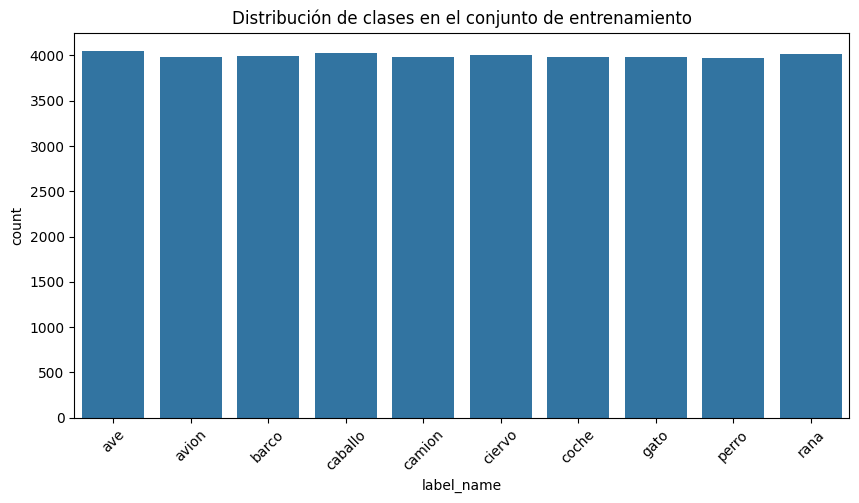

In [8]:
df_labels = pd.DataFrame(y_train, columns=['label'])
df_labels['label_name'] = df_labels['label'].map(MAP_ELEMENTS)

# Gráfico de conteo
plt.figure(figsize=(10, 5))
sns.countplot(x='label_name', data=df_labels, order=sorted(MAP_ELEMENTS.values()))
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xticks(rotation=45)
plt.show()


Como podemos ver, el dataset está muy balanceado, por lo que no habrá que tomar ninguna medida respecto a esto

## Modelos

### Perceptrón multicapa

Ya sabemos que un perceptrón multicapa no va a poder tener muy buenos resultados en un dataset con imágenes algo complejas. Vamos a ver los resultados para luego poder compararlo con los modelos de redes convolucionales.

In [9]:
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_valid_flat = x_valid.reshape((x_valid.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))

model_configs = [
    [256],
    [512, 128],
    [1024, 512, 128]
]


Entrenando MLP con arquitectura: [256]
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2171 - loss: 2.1843 - val_accuracy: 0.3214 - val_loss: 1.8698
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2938 - loss: 1.9306 - val_accuracy: 0.3592 - val_loss: 1.8169
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3093 - loss: 1.8872 - val_accuracy: 0.3652 - val_loss: 1.7916
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3168 - loss: 1.8684 - val_accuracy: 0.3859 - val_loss: 1.7662
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3219 - loss: 1.8404 - val_accuracy: 0.3651 - val_loss: 1.7940
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3344 - loss: 1.8290 - val_accuracy: 0.3749 - val_loss: 1.7369
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3343 - loss: 1.8232 - val_accuracy: 0.3659 - val_loss: 1.7624
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 

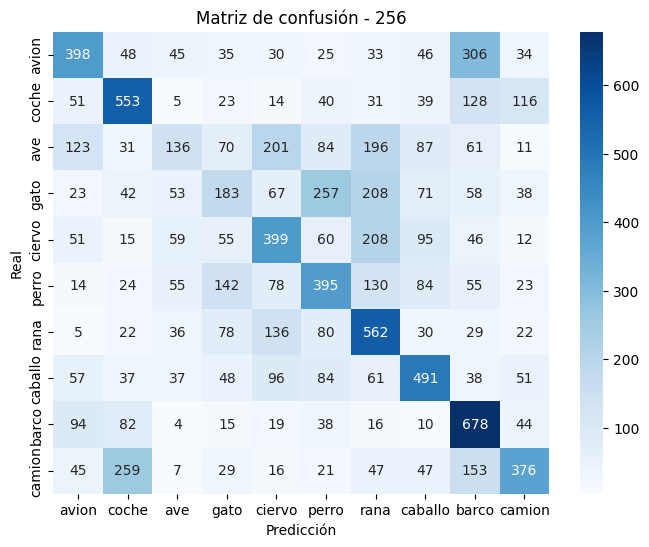


Entrenando MLP con arquitectura: [512, 128]
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.1583 - loss: 2.3059 - val_accuracy: 0.3064 - val_loss: 1.9095
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2771 - loss: 1.9701 - val_accuracy: 0.3361 - val_loss: 1.8490
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2928 - loss: 1.9142 - val_accuracy: 0.3468 - val_loss: 1.8273
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3058 - loss: 1.8768 - val_accuracy: 0.3503 - val_loss: 1.8269
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3251 - loss: 1.8473 - val_accuracy: 0.3658 - val_loss: 1.7723
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3391 - loss: 1.8059 - val_accuracy: 0.3742 - val_loss: 1.7674
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3435 - loss: 1.7896 - val_accuracy: 0.3735 - val_loss: 1.7530
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accur

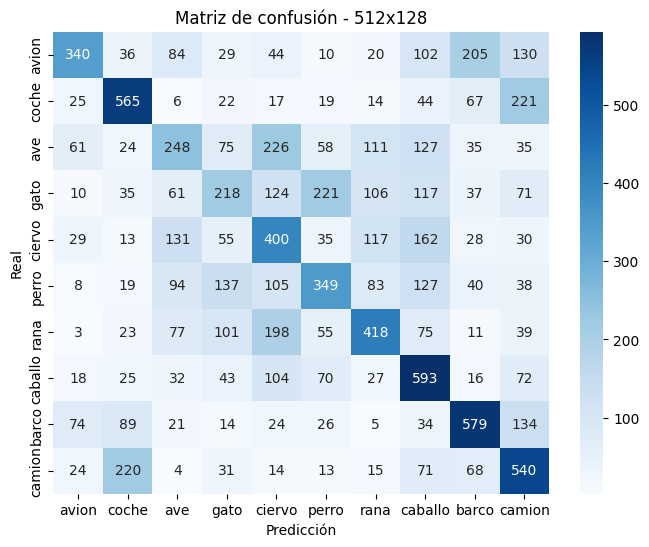


Entrenando MLP con arquitectura: [1024, 512, 128]
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.1664 - loss: 2.2593 - val_accuracy: 0.2915 - val_loss: 1.9299
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2701 - loss: 1.9737 - val_accuracy: 0.3157 - val_loss: 1.8986
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2945 - loss: 1.9225 - val_accuracy: 0.3320 - val_loss: 1.8347
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3073 - loss: 1.8818 - val_accuracy: 0.3267 - val_loss: 1.8427
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3188 - loss: 1.8534 - val_accuracy: 0.3513 - val_loss: 1.7959
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3233 - loss: 1.8407 - val_accuracy: 0.3761 - val_loss: 1.7470
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3394 - loss: 1.8150 - val_accuracy: 0.3771 - val_loss: 1.7390
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step -

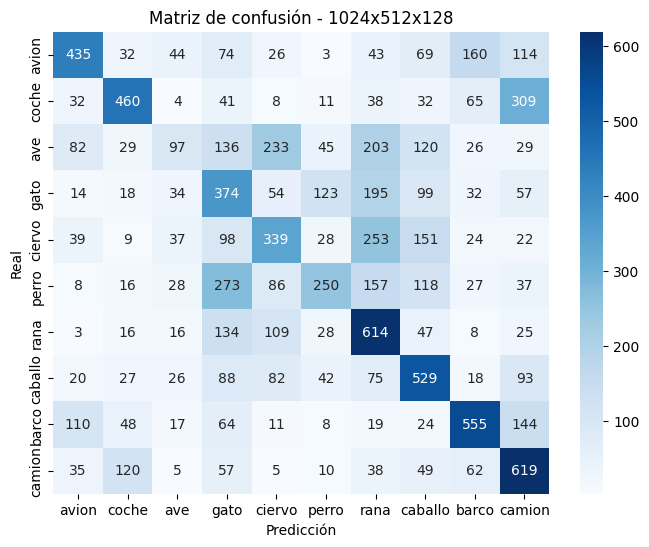

In [10]:
results = []

for config in model_configs:
    model_name = 'x'.join(map(str, config))
    print(f"\nEntrenando MLP con arquitectura: {config}")

    model = Sequential()
    model.add(Input(shape=(x_train_flat.shape[1],)))

    for units in config:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.3))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train_flat, y_train_one_hot,
                        validation_data=(x_valid_flat, y_valid_one_hot),
                        epochs=20, batch_size=64, verbose=1)

    # Evaluación
    y_pred_probs = model.predict(x_test_flat)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_one_hot, axis=1)

    # Calcular accuracy global en test
    test_accuracy = accuracy_score(y_true, y_pred)

    # Reporte de métricas por clase
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    class_metrics = df_report.loc[:'9'][['precision', 'recall']]
    class_metrics.index = [MAP_ELEMENTS[int(i)] for i in class_metrics.index]

    # Guardar resultados
    results.append((model_name, class_metrics, test_accuracy))

    # Matriz de confusión
    print(f"\nMatriz de confusión para modelo {config}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=MAP_ELEMENTS.values(),
                yticklabels=MAP_ELEMENTS.values())
    plt.title(f'Matriz de confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()


In [11]:
for name, metrics_df, acc in results:
    print(f"\n=== Modelo {name} ===")
    print(f"Accuracy global en test: {acc*100:.2f}%")
    print(metrics_df.round(3).to_string())


=== Modelo 256 ===
Accuracy global en test: 41.71%
         precision  recall
avion        0.462   0.398
coche        0.497   0.553
ave          0.311   0.136
gato         0.270   0.183
ciervo       0.378   0.399
perro        0.364   0.395
rana         0.377   0.562
caballo      0.491   0.491
barco        0.437   0.678
camion       0.517   0.376

=== Modelo 512x128 ===
Accuracy global en test: 42.50%
         precision  recall
avion        0.574   0.340
coche        0.539   0.565
ave          0.327   0.248
gato         0.301   0.218
ciervo       0.318   0.400
perro        0.408   0.349
rana         0.456   0.418
caballo      0.408   0.593
barco        0.533   0.579
camion       0.412   0.540

=== Modelo 1024x512x128 ===
Accuracy global en test: 42.72%
         precision  recall
avion        0.559   0.435
coche        0.594   0.460
ave          0.315   0.097
gato         0.279   0.374
ciervo       0.356   0.339
perro        0.456   0.250
rana         0.376   0.614
caballo      0.427   

Como podemos ver hay accuraccy que ronda el 40%, por lo que podemos decir que los modelos son muy malos. Podemos ver que aumentar la profundidad y el número de neuronas por en las capas mejora el modelo un poco. Vamos a realizar unas pruebas con redes convolucionales.

### Redes convolucionales

In [12]:
cnn_configs = {
    'CNN_1conv': 1,
    'CNN_2conv': 2,
    'CNN_3conv': 3,
    'CNN_4conv': 4
}


Entrenando modelo: CNN_1conv

Resumen del modelo CNN_1conv:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,018 (4.01 MB)

 Trainable params: 1,050,954 (4.01 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3189 - loss: 1.9663 - val_accuracy: 0.4943 - val_loss: 1.4729
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4870 - loss: 1.4197 - val_accuracy: 0.4748 - val_loss: 1.4871
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5369 - loss: 1.2876 - val_accuracy: 0.5723 - val_loss: 1.2211
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5758 - loss: 1.1859 - val_accuracy: 0.5929 - val_loss: 1.1532
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6061 - loss: 1.0949 - val_accuracy: 0.5419 - val_loss: 1.3764
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6291 - loss: 1.0260 - val_accuracy: 0.5985 - val_loss: 1.1331
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6579 - loss: 0.9626 - val_accuracy: 0.5767 - val_loss: 1.2731
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6699 - loss: 0.9229 - val_accuracy: 0.

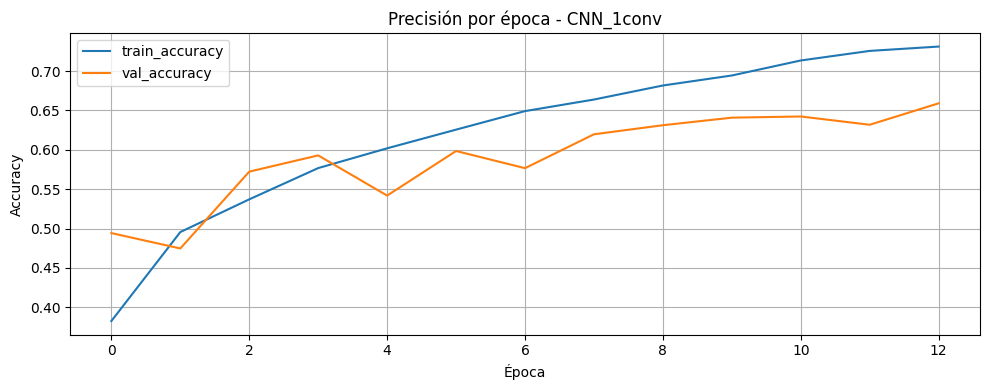

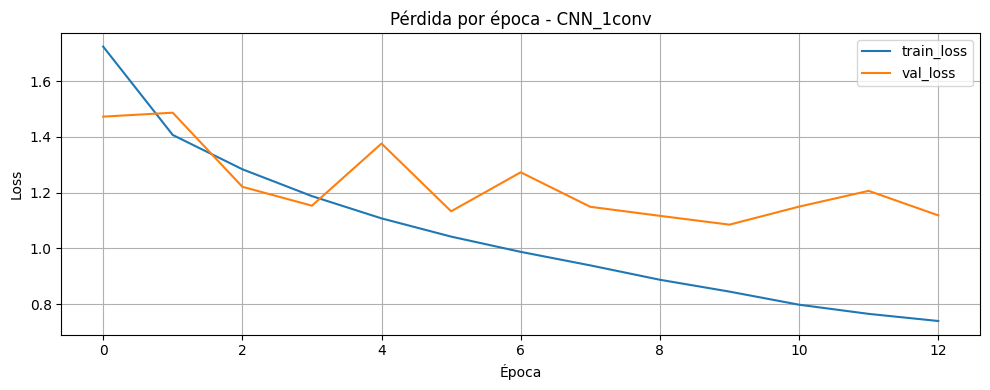

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Matriz de confusión para CNN_1conv


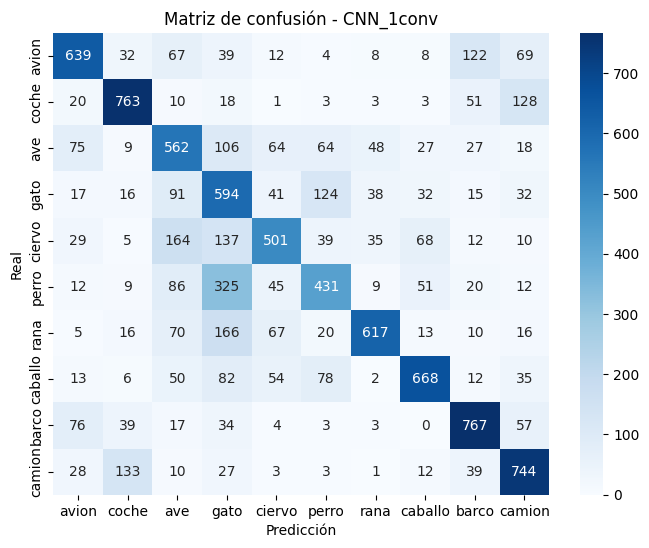


Entrenando modelo: CNN_2conv

Resumen del modelo CNN_2conv:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2994 - loss: 2.0003 - val_accuracy: 0.3665 - val_loss: 1.8097
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4747 - loss: 1.4384 - val_accuracy: 0.4502 - val_loss: 1.5678
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5508 - loss: 1.2615 - val_accuracy: 0.5663 - val_loss: 1.2284
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5934 - loss: 1.1418 - val_accuracy: 0.6164 - val_loss: 1.0830
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6271 - loss: 1.0581 - val_accuracy: 0.6546 - val_loss: 0.9932
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6528 - loss: 0.9875 - val_accuracy: 0.6740 - val_loss: 0.9591
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6727 - loss: 0.9182 - val_accuracy: 0.6625 - val_loss: 1.0412
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6963 - loss: 0.8589 - val_accuracy: 0.

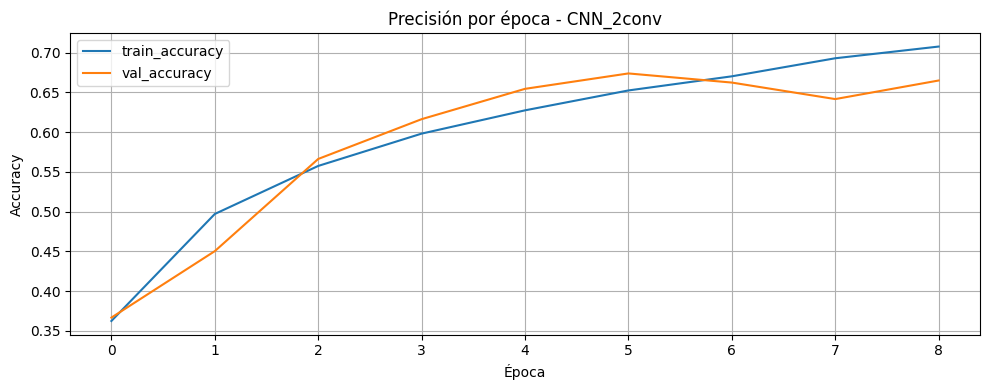

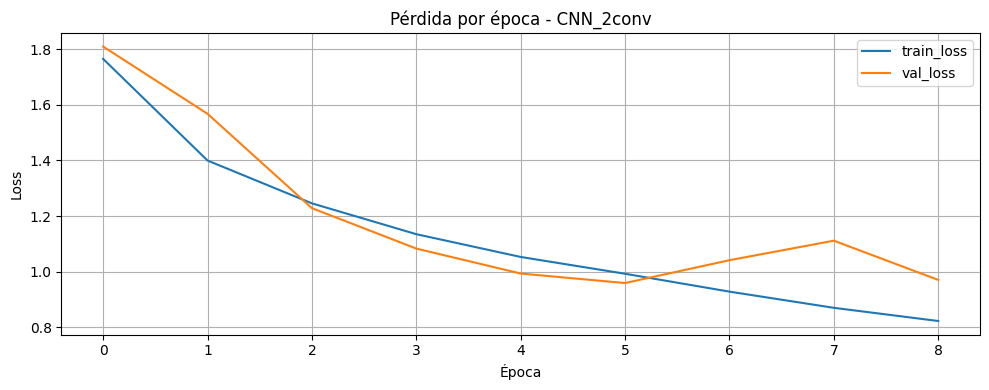

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Matriz de confusión para CNN_2conv


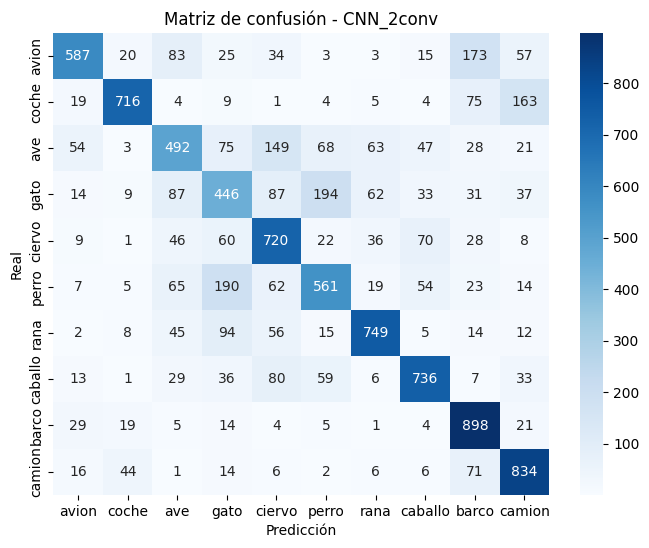


Entrenando modelo: CNN_3conv

Resumen del modelo CNN_3conv:


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3246 - loss: 1.9419 - val_accuracy: 0.4833 - val_loss: 1.4475
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5145 - loss: 1.3584 - val_accuracy: 0.5434 - val_loss: 1.3625
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5928 - loss: 1.1400 - val_accuracy: 0.5538 - val_loss: 1.2542
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6477 - loss: 0.9984 - val_accuracy: 0.6322 - val_loss: 1.0669
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6847 - loss: 0.8983 - val_accuracy: 0.6204 - val_loss: 1.1429
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7165 - loss: 0.8196 - val_accuracy: 0.6194 - val_loss: 1.1628
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7386 - loss: 0.7464 - val_accuracy: 0.7076 - val_loss: 0.8670
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7662 - loss: 0.6718 - val_accuracy: 0.

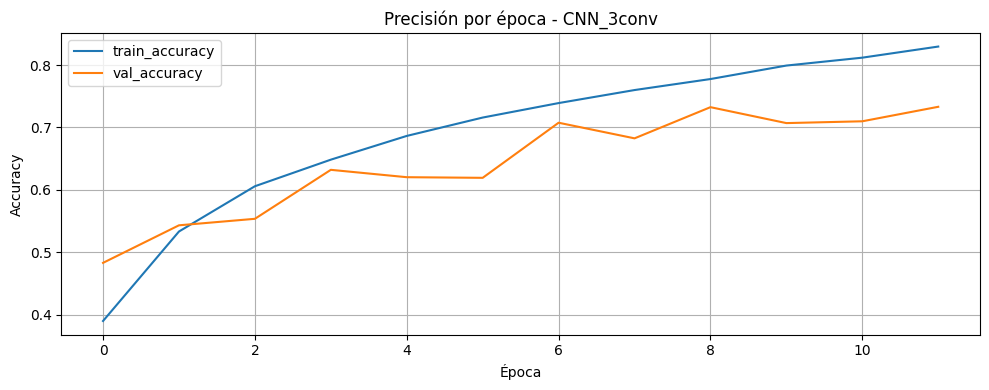

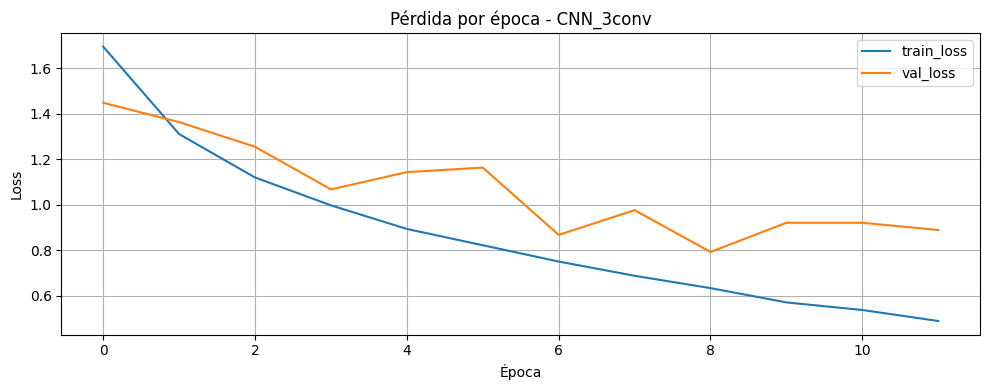

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Matriz de confusión para CNN_3conv


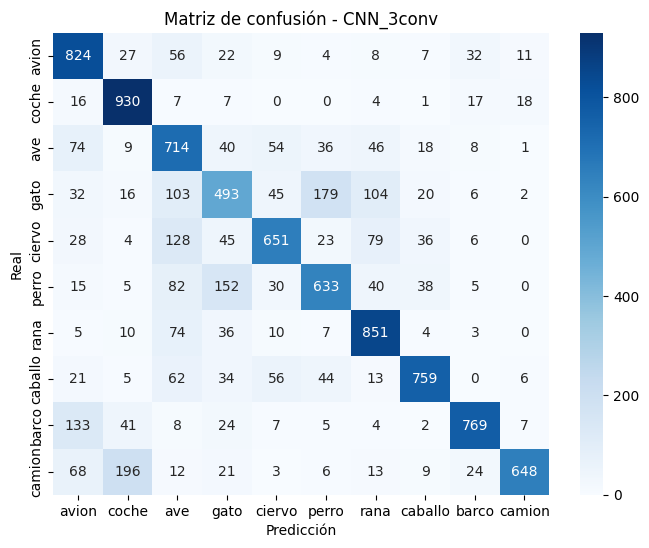


Entrenando modelo: CNN_4conv

Resumen del modelo CNN_4conv:


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,826 (1.99 MB)

 Trainable params: 521,866 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3342 - loss: 1.9093 - val_accuracy: 0.4658 - val_loss: 1.5561
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5415 - loss: 1.2863 - val_accuracy: 0.6096 - val_loss: 1.1374
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6339 - loss: 1.0411 - val_accuracy: 0.6312 - val_loss: 1.0521
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7007 - loss: 0.8747 - val_accuracy: 0.6683 - val_loss: 0.9665
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7445 - loss: 0.7412 - val_accuracy: 0.6904 - val_loss: 0.9255
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7801 - loss: 0.6439 - val_accuracy: 0.6142 - val_loss: 1.2137
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8093 - loss: 0.5583 - val_accuracy: 0.7311 - val_loss: 0.8462
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8349 - loss: 0.4822 - val_accuracy: 0

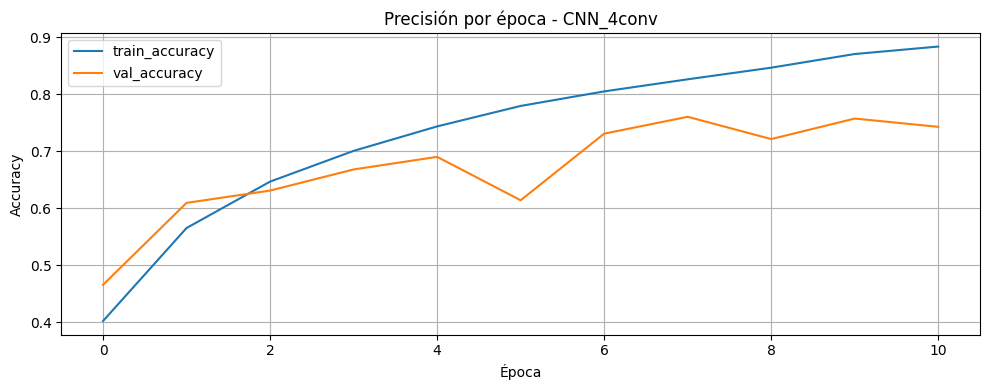

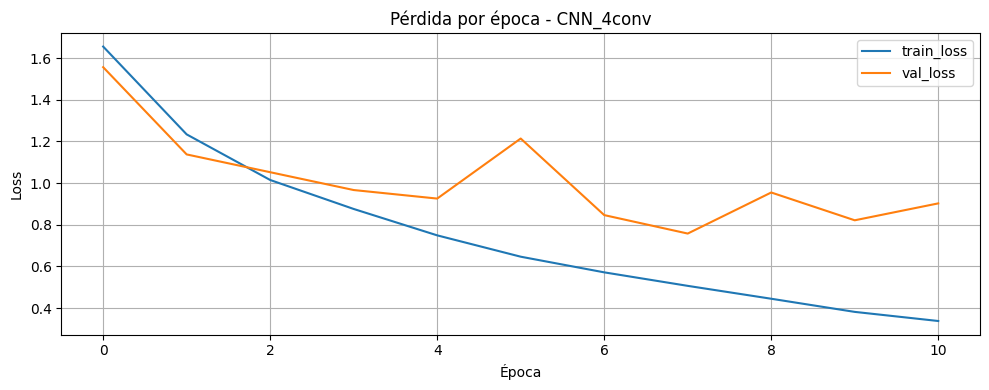

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Matriz de confusión para CNN_4conv


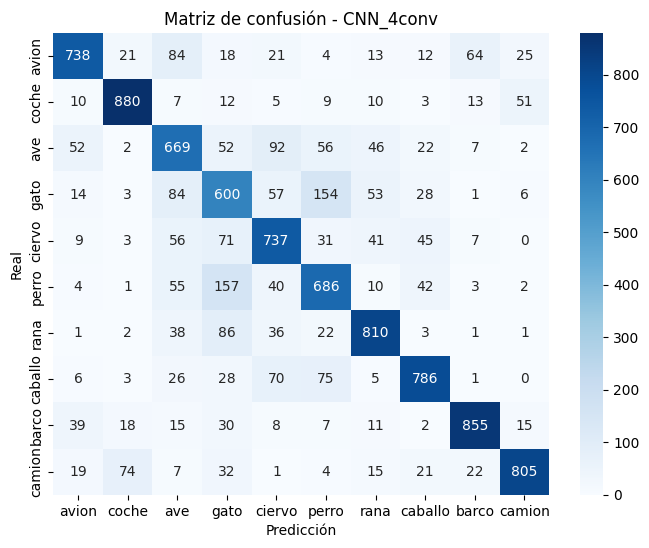

In [18]:
results = []

for name, num_convs in cnn_configs.items():
    print(f"\nEntrenando modelo: {name}")

    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))

    filters = 32
    for i in range(num_convs):
        model.add(Conv2D(filters, (3, 3), activation='relu', padding='same'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        filters *= 2  # Duplicar filtros cada capa

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    print(f"\nResumen del modelo {name}:")
    model.summary()

    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(x_train, y_train_one_hot,
                        validation_data=(x_valid, y_valid_one_hot),
                        epochs=30,
                        batch_size=64,
                        callbacks=[early_stop],
                        verbose=1)

    # Graficar precisión
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(f'Precisión por época - {name}')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Graficar pérdida
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'Pérdida por época - {name}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # Evaluación
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_one_hot, axis=1)

    # Accuracy
    test_acc = accuracy_score(y_true, y_pred)

    # Métricas por clase
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    class_metrics = df_report.loc[:'9'][['precision', 'recall']]
    class_metrics.index = [MAP_ELEMENTS[int(i)] for i in class_metrics.index]

    results.append((name, class_metrics, test_acc))

    # Matriz de confusión
    print(f"\nMatriz de confusión para {name}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=MAP_ELEMENTS.values(),
                yticklabels=MAP_ELEMENTS.values())
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()


In [15]:
for name, metrics_df, acc in results:
    print(f"\n=== Modelo {name} ===")
    print(f"Accuracy global en test: {acc*100:.2f}%")
    print(metrics_df.round(3).to_string())



=== Modelo CNN_1conv ===
Accuracy global en test: 58.30%
         precision  recall
avion        0.616   0.657
coche        0.735   0.683
ave          0.574   0.240
gato         0.345   0.466
ciervo       0.639   0.380
perro        0.444   0.530
rana         0.608   0.776
caballo      0.626   0.672
barco        0.732   0.682
camion       0.638   0.744

=== Modelo CNN_2conv ===
Accuracy global en test: 71.65%
         precision  recall
avion        0.768   0.766
coche        0.873   0.783
ave          0.588   0.630
gato         0.501   0.516
ciervo       0.655   0.694
perro        0.720   0.529
rana         0.716   0.818
caballo      0.762   0.781
barco        0.870   0.797
camion       0.756   0.851

=== Modelo CNN_3conv ===
Accuracy global en test: 67.80%
         precision  recall
avion        0.682   0.747
coche        0.733   0.867
ave          0.595   0.556
gato         0.540   0.409
ciervo       0.692   0.517
perro        0.622   0.555
rana         0.750   0.759
caballo      0.6

### Comparación de resultados

Como podemos ver en la siguiente tabla, los resultados de las distintas redes convolucionales son bastante mejores que las de los perceptrones multicapa.

| Modelo                  | Accuracy Test |
| ----------------------- | ------------- |
| **MLP \[256]**          | 41.71%        |
| **MLP \[512,128]**      | 42.50%        |
| **MLP \[1024,512,128]** | 42.72%        |
| **CNN 1 capa**          | 58.30%        |
| **CNN 2 capas**         | 71.65%        |
| **CNN 3 capas**         | 67.80%        |
| **CNN 4 capas**         | 71.46%        |

Esto se debe a que las CNN están especificamente diseñadas para trabajar con imágenes, a diferencia a los perceptrones multicapa, que tratan las imágenes como vectores planos.

Las CNN procesan las imágenes en 2D, manteniendo relaciones entre píxeles cercanos, lo cual es esencial para detectar bordes, texturas y formas.


#### Análisis de métricas: Precisión y recall

Primero vamos a explicar lo que son las metricas.

- Precisión: mide la calidad de las predicciones positivas. Es decir, si predecimos coches, de todas las veces que dice que es un coche, cuantas son verdad.

- Recall: mide la cobertura de las verdaderas etiquetas. Es decir, de todos los coches que había, cuantos detectó correctamente la red.

En los mejores modelos de CNN (2 capas y 4) las clases con alta precisión y recall son camión, barco, coche y rana. Esto puede ser a que son más distintivos visualmente, con formas grandes y fáciles de detectar.

In [ ]:
# Ver imágenes mal clasificadas
incorrect_idxs = np.where(y_pred != y_true)[0]
plt.figure(figsize=(10, 10))
for i, idx in enumerate(incorrect_idxs[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"Pred: {MAP_ELEMENTS[y_pred[idx]]}, Real: {MAP_ELEMENTS[y_true[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


### Preentrenados

In [19]:
import tensorflow as tf

vgg_model = tf.keras.applications.vgg16.VGG16(weights='imagenet', include_top = False ,classes = 10, input_shape=(32, 32, 3))
# ResNet = tf.keras.applications.resnet50.ResNet50()
# MobileNet = tf.keras.applications.mobilenet_v2.MobileNetV2()
# EfficientNet = tf.keras.applications.efficientnet.EfficientNetB0()

In [20]:
last = vgg_model.get_layer('block3_pool').output

In [21]:
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(10, activation='softmax')(x)

model = Model(vgg_model.input, x)


In [22]:
for layer in vgg_model.layers:
    layer.trainable = False

#compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,836,490 (7.01 MB)

 Trainable params: 100,490 (392.54 KB)

 Non-trainable params: 1,736,000 (6.62 MB)

In [24]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [25]:
history = model.fit(x_train, y_train_one_hot,
                    validation_data=(x_valid, y_valid_one_hot),
                    epochs=30,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.3683 - loss: 1.8396 - val_accuracy: 0.6361 - val_loss: 1.0680
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5707 - loss: 1.2380 - val_accuracy: 0.6662 - val_loss: 0.9740
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6071 - loss: 1.1424 - val_accuracy: 0.6860 - val_loss: 0.9131
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6313 - loss: 1.0622 - val_accuracy: 0.6971 - val_loss: 0.8735
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6433 - loss: 1.0304 - val_accuracy: 0.7040 - val_loss: 0.8610
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6569 - loss: 0.9982 - val_accuracy: 0.7069 - val_loss: 0.8407
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6602 - loss: 0.9830 - val_accuracy: 0.7136 - val_loss: 0.8231
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6738 - loss: 0.9541 - val_acc

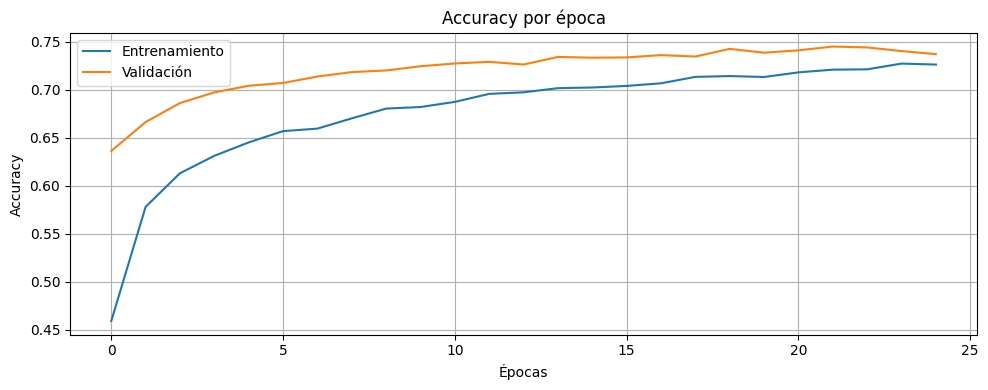

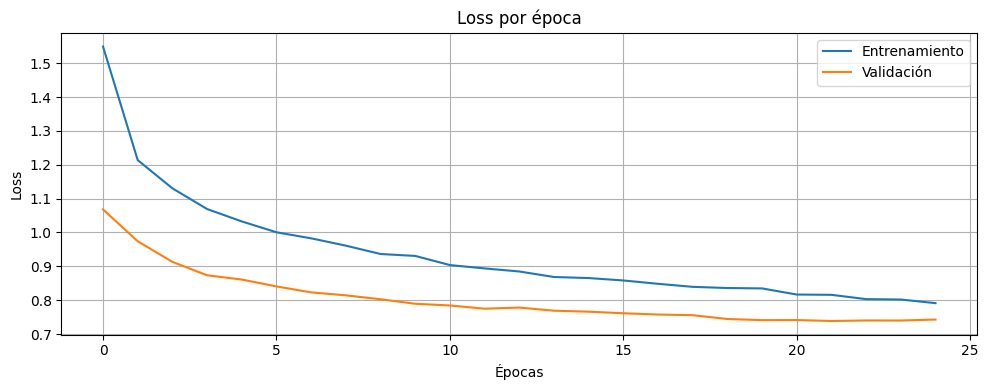

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

Accuracy global en el conjunto de test (VGG16): 73.95%

Métricas por clase en el conjunto de test (VGG16):
         precision  recall  f1-score  support
avion        0.785   0.774     0.779   1000.0
coche        0.797   0.854     0.825   1000.0
ave          0.703   0.635     0.667   1000.0
gato         0.584   0.531     0.556   1000.0
ciervo       0.658   0.741     0.697   1000.0
perro        0.658   0.647     0.653   1000.0
rana         0.741   0.820     0.778   1000.0
caballo      0.805   0.777     0.791   1000.0
barco        0.860   0.830     0.845   1000.0
camion       0.798   0.786     0.792   1000.0

Matriz de confusión en el conjunto de test (VGG16)


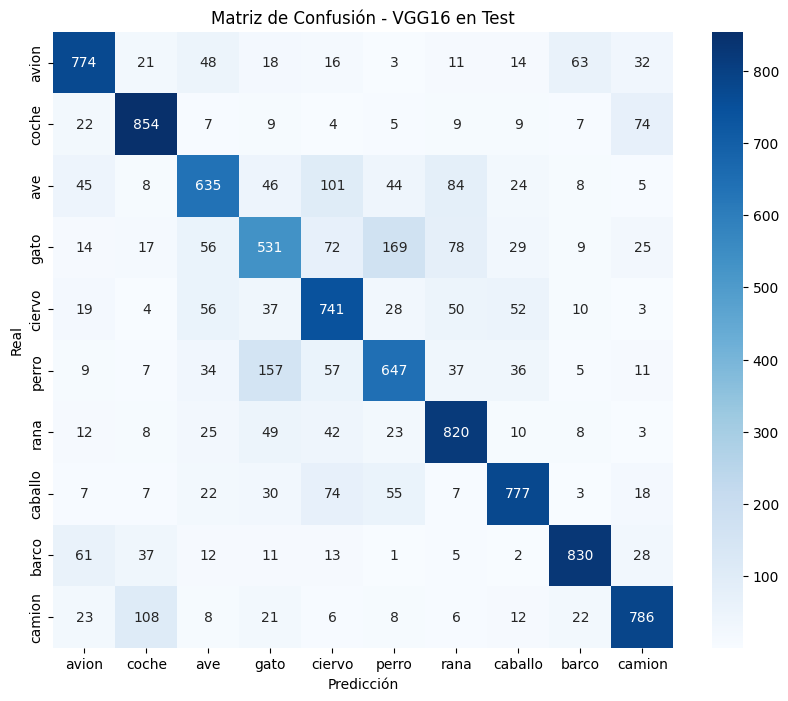

In [28]:
# Obtener predicciones desde el dataset de test
#y_pred_probs = model.predict(test_ds) # Original line
y_pred_probs_test = model.predict(x_test) # Changed line
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test_one_hot, axis=1)

# Calcular accuracy global en test
test_accuracy = accuracy_score(y_true_test, y_pred_test)
print(f"\nAccuracy global en el conjunto de test (VGG16): {test_accuracy*100:.2f}%")

# Reporte de métricas por clase en test
report_test = classification_report(y_true_test, y_pred_test, output_dict=True, zero_division=0)
df_report_test = pd.DataFrame(report_test).transpose()
class_metrics_test = df_report_test.loc[:'9'][['precision', 'recall', 'f1-score', 'support']]
class_metrics_test.index = [MAP_ELEMENTS[int(i)] for i in class_metrics_test.index]

print("\nMétricas por clase en el conjunto de test (VGG16):")
print(class_metrics_test.round(3).to_string())

# Matriz de confusión en test
print("\nMatriz de confusión en el conjunto de test (VGG16)")
cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=MAP_ELEMENTS.values(),
            yticklabels=MAP_ELEMENTS.values())
plt.title('Matriz de Confusión - VGG16 en Test')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

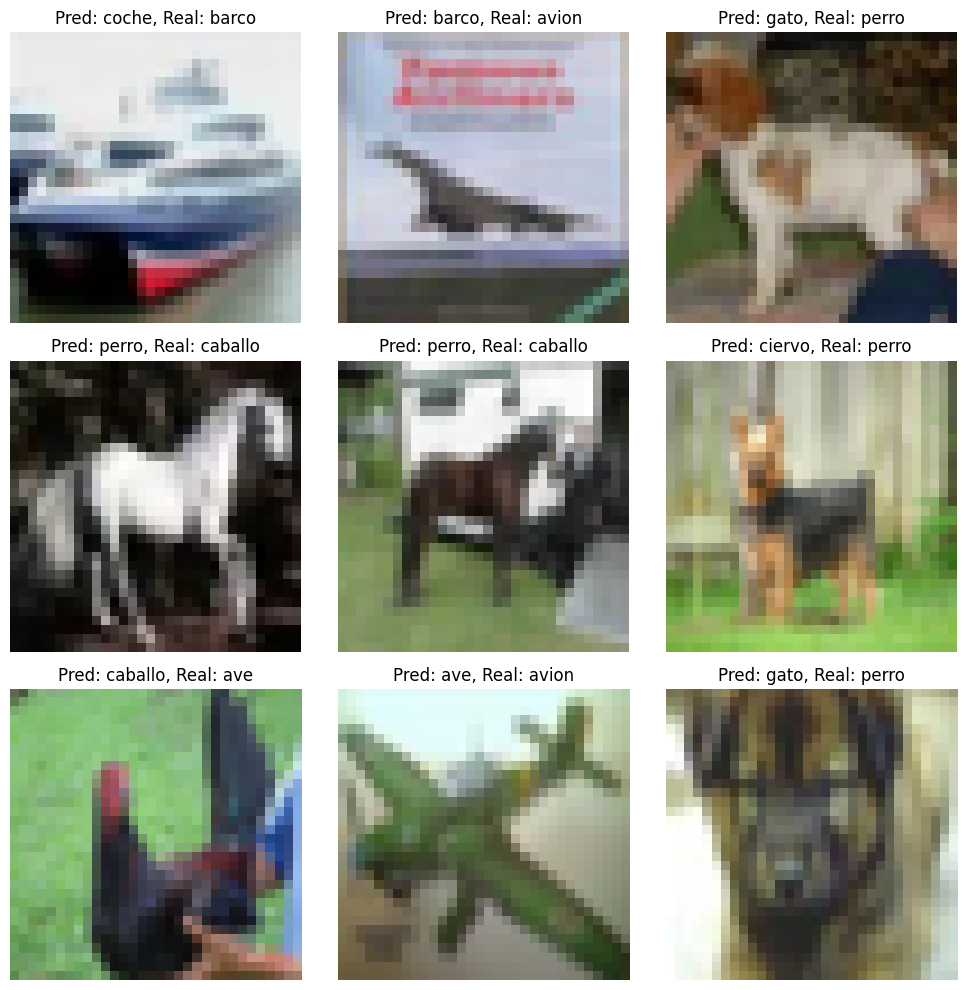

In [32]:
# Ver imágenes mal clasificadas
incorrect_idxs = np.where(y_pred_test != y_true_test)[0]
plt.figure(figsize=(10, 10))
for i, idx in enumerate(incorrect_idxs[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"Pred: {MAP_ELEMENTS[y_pred_test[idx]]}, Real: {MAP_ELEMENTS[y_true_test[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()